In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1" #set cores for numpy
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR') #no info and warnings are printed 
tf.config.threading.set_inter_op_parallelism_threads(1) #set cores for TF
tf.config.threading.set_intra_op_parallelism_threads(1)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
print(gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

%matplotlib inline
import matplotlib.pyplot as plt
import h5py
import time
from pathlib import Path
import matplotlib as mpl
# plt.style.use('dark_background')

#Latex
# mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')

#
import scipy.io


Num GPUs Available:  0
[]


## Load Data

In [2]:
data = scipy.io.loadmat('/Users/animesh/Documents/PhD/Fourth Year/PINN/Data_PINN_ff0.01He0N551_subsonic.mat')

eta = data['eta']
pi_p = data['pi_p']
pi_m = data['pi_m']
sig = data['sig']

N1 = eta.shape[1]

U = np.zeros((N1,4),dtype=float)
U[:,0] = eta
U[:,1] = pi_p
U[:,2] = pi_m
U[:,3] = sig

D = data['D']
M = data['M']
u = data['ubar']
dMdx = data['dMdx']
dudx = data['dudx']
alpha = data['alp']
eta1 = data['eta']    

meanflow = np.zeros((N1,7),dtype=np.float)


meanflow[:,0] = D
meanflow[:,1] = M
meanflow[:,2] = u
meanflow[:,3] = dMdx
meanflow[:,4] = dudx
meanflow[:,5] = alpha
meanflow[:,6] = eta1

The governing equations for the prediction of entropy waves after Fourier transform are \citep{jain_magri_2022},
\begin{align}
    \frac{d\pi^+}{d\eta} &= \left(2\pi i He \varrho^+ + \Gamma^-\kappa^- + \mathcal{M}\right)\pi^+ - \left(2\pi i He \varkappa^+ + \Gamma^-\kappa^+ + \mathcal{M}\right)\pi^- + \Gamma^-\sigma \label{eq:piplus}\\
    \frac{d\pi^-}{d\eta} &=  \left(2\pi i He \varkappa^- + \Gamma^+\kappa^- - \mathcal{M}\right)\pi^+ + \left(2\pi i He \varrho^- + \Gamma^+\kappa^+ + \mathcal{M}\right)\pi^- + \Gamma^+\sigma \\
    \frac{d\sigma}{d\eta} &= \left(2\pi i He \vartheta^+ + \Upsilon\kappa^- \right)\pi^+ + \left(2\pi i He \vartheta^- + \Upsilon\kappa^+\right)\pi^- + \left(2\pi i He\varsigma + \Upsilon\right)\sigma\label{eq:sigma}
\end{align}
where $\pi^\pm$ are downstream and upstream propagating acoustic waves, $\sigma$ is the temperature inhomogeneity wave,
$He$ is the Helmholtz number,
$\eta$ is the normalized spatial location,
$\varrho = \varrho\left(\eta, M, f, \alpha\right)$,
$\varkappa = \varkappa\left(\eta, M, f, \alpha\right)$,
$\vartheta = \vartheta\left(\eta, M, f, \alpha\right)$,
$\varsigma = \varsigma\left(\eta, M, f, \alpha\right)$,
$\mathcal{M} = \mathcal{M}\left(\eta, M, dM/d\eta\right)$,
$\kappa = \kappa\left(\eta, M\right)$,
$\Gamma = \Gamma\left(\eta, M, dM/d\eta, f, \alpha \right)$
$\Upsilon = \Upsilon\left(\eta, M, dM/d\eta, f, \alpha\right)$,
$M$ is the Mach number,
$f$ is the friction factor, and
$\tan\alpha$ is the spatial derivative of the nozzle geometry.

In [3]:
#Right hand side of the governing equations
def RHS_ff(x,y, baseflow):
    eta = x
    pi_p, pi_m, sig = tf.unstack(y,axis=1)


    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0#a constant input

    gamma = 1.4#constant
    
    Msq = tf.math.square(M)

    f =  0.01 #Variable (parameter of the network)
    
    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*tf.math.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    


    denom = (M**2*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    




#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
    
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)
    eq1 = - (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p + calM)*pi_m - Gm_m*sig
    eq2 = - ( Gm_p*kp_m - calM)*pi_p - ( Gm_p*kp_p + calM)*pi_m - Gm_m*sig
    eq3 = - ( Ups*kp_m)*pi_p - ( Ups*kp_p)*pi_m - (Ups)*sig
    




    return tf.stack([-eq1, -eq2, -eq3],axis=1)

#### Split data

In [4]:
def split_data(U, b_size, n_batches):
    
    '''
    Splits the data in batches. Each batch is created by sampling the signal with interval
    equal to n_batches.
    '''
    data   = np.zeros((n_batches, b_size, U.shape[1]), dtype=float)    
    for j in range(n_batches):
        data[j,:b_size] = U[::skip][j::n_batches].copy()

    return data

Train Data%  : 0.8166969147005445
Val   Data%  : 0.0
(450, 3) (450, 3)
tf.Tensor(0.31801313161849976, shape=(), dtype=float64) tf.Tensor(0.12981539964675903, shape=(), dtype=float64)


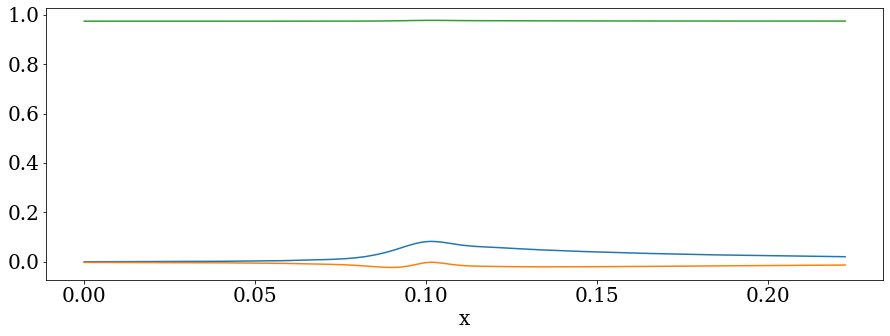

In [5]:
b_size      = 30             #batch_size
n_batches   = 5              #number of batches
val_batches = n_batches//10   #validation batches
skip        = 3              #we sample the data at every skip step


print('Train Data%  :',b_size*n_batches*skip/U.shape[0]) #how much of the data we are using for training
print('Val   Data%  :',b_size*val_batches*skip/U.shape[0])

# training data
x_tt        = U[:b_size*n_batches*skip][:,:1].copy()                      #to be used for random batches
Y_tt        = U[:b_size*n_batches*skip][:,1:].copy().astype(dtype=float) 
meanflow_tt = meanflow[:b_size*n_batches*skip].copy()

Y_train     = split_data(Y_tt, b_size, n_batches).astype(dtype=float)
x_train     = split_data(x_tt, b_size, n_batches).astype(dtype=float)

baseflow_train = split_data(meanflow_tt, b_size, n_batches).astype(dtype=float)
# validation data
x_vv        = U[b_size*n_batches*skip:b_size*n_batches*skip+b_size*val_batches*skip:][:,:1].copy()
Y_vv        = U[b_size*n_batches*skip:b_size*n_batches*skip+b_size*val_batches*skip:][:,1:].copy()
meanflow_vv = meanflow[b_size*n_batches*skip:b_size*n_batches*skip+b_size*val_batches*skip:].copy()
Y_val       = split_data(Y_vv, b_size, val_batches).astype(dtype=float) 
x_val       = split_data(x_vv, b_size, val_batches).astype(dtype=float)
baseflow_vv = split_data(meanflow_vv, b_size, val_batches).astype(dtype=float)

rng = np.random.default_rng() #random generator for later shuffling

Loss_Mse    = tf.keras.losses.MeanSquaredError()
print(RHS_ff(x_tt,Y_tt, meanflow_tt).shape, Y_tt.shape)
norm_der    = Loss_Mse(RHS_ff(x_tt,Y_tt, meanflow_tt), Y_tt*0)
Y_norm      = (Y_train.max() - Y_train.min())
Y_train     = Y_train /Y_norm
norm        = Loss_Mse(Y_train, Y_train*0)
print(norm, norm_der)


plt.rcParams["figure.figsize"] = (15,5)
plt.rcParams["font.size"]  = 20
ax = plt.plot(x_train[0], Y_train[0])
plt.xlabel('x')
# plt.ylabel('epochs')

# plt.axes().get_xaxis().set_visible(True)
# plt.axes().get_yaxis().set_visible(True)
# ax.set_frame_on(True)
plt.show()

del Y_vv,Y_tt,x_tt,x_vv

## Neural Network

#### Estimation of friction factor, f



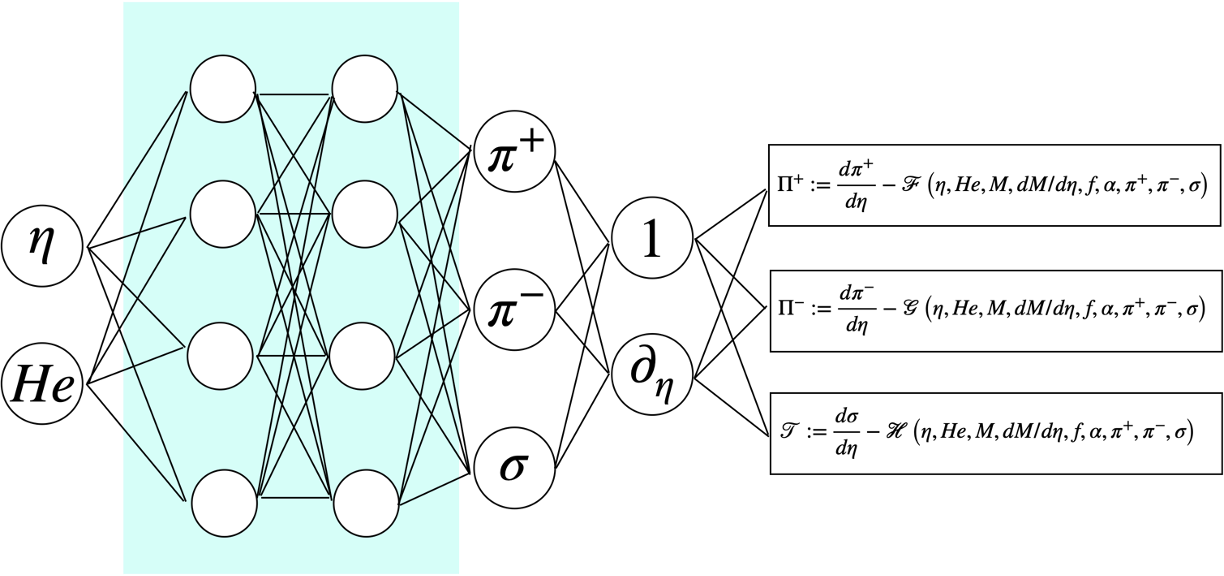


We define $\Pi^+$, $\Pi^-$ and $\mathcal{T}$ as,
\begin{align}
    \Pi^+ &:= \frac{d\pi^+}{d\eta} - \mathcal{F}\left(\eta, He, M, dM/d\eta, f, \alpha, \pi^+, \pi^-, \sigma \right)\\
    \Pi^- &:= \frac{d\pi^-}{d\eta} - \mathcal{G}\left(\eta, He, M, dM/d\eta, f, \alpha, \pi^+, \pi^-, \sigma \right)\\
    \mathcal{T} &:= \frac{d\sigma}{d\eta} - \mathcal{H}\left(\eta, He, M, dM/d\eta, f, \alpha, \pi^+, \pi^-, \sigma \right)
\end{align}

Based on the method proposed by \citet{raissi2019physics}, the parameters $[\pi^+ ~ \pi^- ~ \sigma]$ and $[f]$ can be jointly trained by minimising the mean square error loss,

\begin{align}
    MSE &:= \frac{1}{N}\sum_{i=1}^N \left(|\pi^+(\eta_i, He_i, M_i) - \pi^+_i|^2 +
    |\pi^-(\eta_i, He_i, M_i) - \pi^-_i|^2+
    |\sigma(\eta_i, He_i, M_i) - \sigma_i|^2
    \right) \ldots\nonumber\\
    &\ldots+\frac{1}{N}\sum_{i=1}^N \left(|\Pi^+(\eta_i, He_i, M_i)|^2+
    |\Pi^-(\eta_i, He_i, M_i)|^2+
    |\mathcal{T}(\eta_i, He_i, M_i)|^2
    \right).\label{eq:mse}
\end{align}

In [6]:
@tf.function #this creates the tf graph
def train_step(inputs, targets, baseflow, model, f, train=True):
    
    """
    Trains the model by minimizing the loss between outputs and targets
    """
    
    outputs     = model(inputs, training=train)
    
    dpi_p_deta       = tf.gradients(outputs[:,0],inputs)
    dpi_m_deta       = tf.gradients(outputs[:,1],inputs)
    dsig_deta       = tf.gradients(outputs[:,2],inputs)

    print('x',dpi_p_deta)
    
#     dq_deta       = tf.concat([dpi_p_deta,dpi_m_deta,dsig_deta],axis=2)/x_max
    dq_deta       = tf.concat([dpi_p_deta,dpi_m_deta,dsig_deta],axis=2)
    
    print('q',dq_deta)
    
    RHS         = RHS_ff(inputs,outputs, baseflow)
    
    print('RHS', RHS)
    
    
    loss1       = Loss_Mse(outputs, targets)
    loss2       = 0.1 #Loss_Mse(dq_dt, RHS)
    
    loss        = loss1/norm #+ loss2/norm_der
    

    # compute and apply gradients inside tf.function environment for computational efficiency
    if train:
        # create a variable with all the weights to perform gradient descent on
        # appending lists is done by plus sign
        varss    = model.trainable_weights + [f]
        
        #compute and apply gradients
        grads   = tf.gradients(loss, varss)
#         grads   = tf.gradients(loss, varss, grad_ys= tf.complex128)
        optimizer.apply_gradients(zip(grads, varss))
    
    return loss1, loss2, outputs

@tf.function #this creates the tf graph
def train_step1(inputs, targets, baseflow, model, f, train=True):
    
    """
    Trains the model by minimizing the loss of the physics
    """

    outputs     = model(inputs, training=train)*Y_norm

    dpi_p_deta       = tf.gradients(outputs[:,0],inputs)
    dpi_m_deta       = tf.gradients(outputs[:,1],inputs)
    dsig_deta       = tf.gradients(outputs[:,2],inputs)
    
    print('x',dpi_p_deta)
    
#     dq_deta       = tf.concat([dpi_p_deta,dpi_m_deta,dsig_deta],axis=2)/x_max
    dq_deta       = tf.concat([dpi_p_deta,dpi_m_deta,dsig_deta],axis=2)
    
    print('q',dq_deta)
    
    RHS         = RHS_ff_t(inputs,outputs, baseflow, f)
    
    print('RHS', RHS)
    
    loss1       = Loss_Mse(outputs/Y_norm, targets)
    loss2       = Loss_Mse(dq_deta, RHS)
    
    loss        = loss1/norm + loss2/norm_der
    

    # compute and apply gradients inside tf.function environment for computational efficiency
    if train:
        # create a variable with all the weights to perform gradient descent on
        # appending lists is done by plus sign
        varss    = [f]
        
        #compute and apply gradients
        grads   = tf.gradients(loss, varss)
        optimizer.apply_gradients(zip(grads, varss))
    
    return loss1, loss2, outputs/Y_norm

In [7]:
dim=3

model = tf.keras.models.Sequential(name='PINN')

model.add(tf.keras.layers.Dense(  units = 64,   activation='tanh', name='Layer1'))
model.add(tf.keras.layers.Dense(  units = 64,   activation='tanh', name='Layer2'))
model.add(tf.keras.layers.Dense(  units = 32,   activation='tanh', name='Layer3'))
# model.add(tf.keras.layers.Dense(  units = 16,   activation='tanh', name='Layer4'))
model.add(tf.keras.layers.Dense(units = dim,  activation='linear', name='Layer5',dtype=tf.float64))

a = model(x_train[0])
model.summary()

# f = tf.Variable(tf.TensorArray(tf.float64, size =b_size*n_batches*skip ), name='f',dtype=tf.float64)
# f = tf.Variable(tf.float64,tf.zeros((1, b_size*n_batches*skip)), name='f')
f = tf.Variable(0.0005, name='f',dtype=tf.float64)
print(f)

# train_step(t_train[0], Y_train[0], model, sigma)
# for j in range(n_batches):
#     loss, loss1  = train_step(t_train[j], Y_train[j], sigma, model1)

Model: "PINN"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Layer1 (Dense)               (30, 64)                  128       
_________________________________________________________________
Layer2 (Dense)               (30, 64)                  4160      
_________________________________________________________________
Layer3 (Dense)               (30, 32)                  2080      
_________________________________________________________________
Layer5 (Dense)               (30, 3)                   99        
Total params: 6,467
Trainable params: 6,467
Non-trainable params: 0
_________________________________________________________________
<tf.Variable 'f:0' shape=() dtype=float64, numpy=0.0005>


x [<tf.Tensor 'gradients/PINN/Cast_grad/Cast:0' shape=(30, 1) dtype=float64>]
q Tensor("concat:0", shape=(1, 30, 3), dtype=float64)
RHS Tensor("stack:0", shape=(30, 3), dtype=float64)
x [<tf.Tensor 'gradients/PINN/Cast_grad/Cast:0' shape=(30, 1) dtype=float64>]
q Tensor("concat:0", shape=(1, 30, 3), dtype=float64)
RHS Tensor("stack:0", shape=(30, 3), dtype=float64)
0.0005


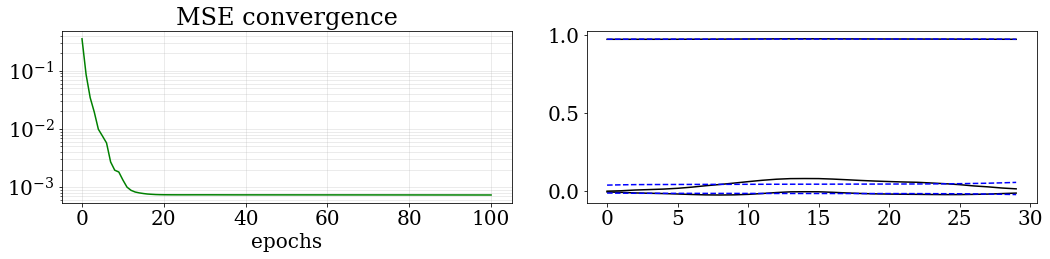

0.0005


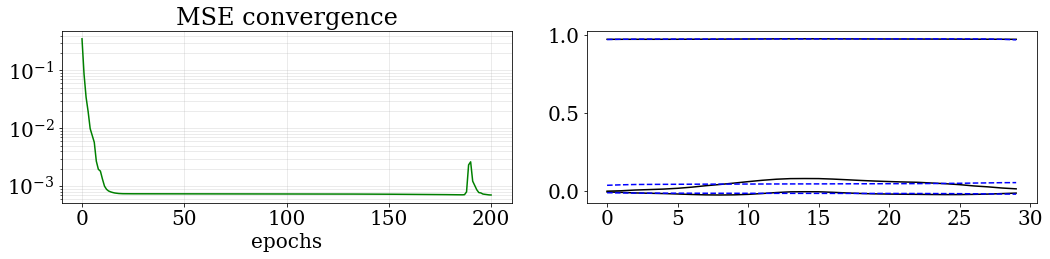

0.0005


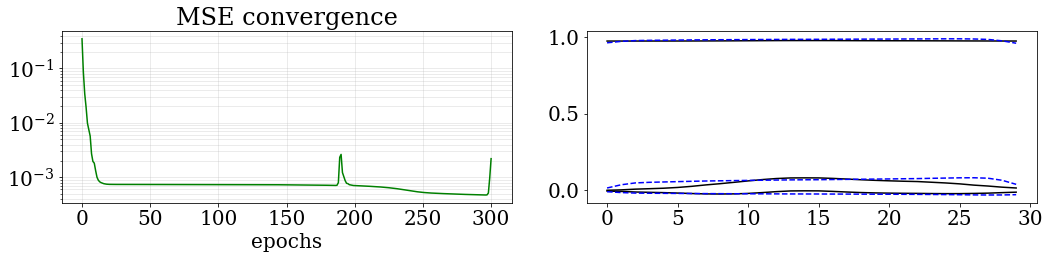

0.0005


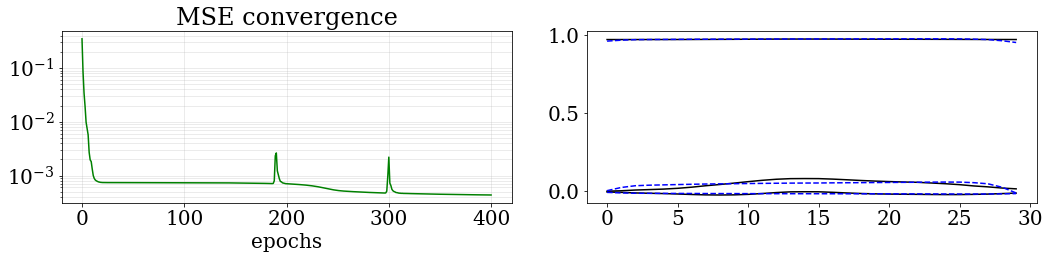

In [8]:
plt.rcParams["figure.figsize"] = (15,4)
plt.rcParams["font.size"]  = 20

Loss_Mse    = tf.keras.losses.MeanSquaredError()

n_epochs    = 5001 #number of epochs

#define optimizer and initial learning rate   
optimizer   = tf.keras.optimizers.Adam(amsgrad=True) #amsgrad True for better convergence
# optimizer   = tf.keras.optimizers.Adam #amsgrad True for better convergence

l_rate                  = 0.01
optimizer.learning_rate = l_rate

# quantities to check and store the training and validation loss and the training goes on
old_loss      = np.zeros(n_epochs) #needed to evaluate training loss convergence
tloss_plot    = np.zeros(n_epochs) #training loss
vloss_plot    = np.zeros(n_epochs) #validation loss
tloss1_plot   = np.zeros(n_epochs) #training_der loss
vloss1_plot   = np.zeros(n_epochs) #validation_der loss
old_loss[0]  = 1e6 #initial value has to be high
N_check      = 5   #each N_check epochs we check convergence and validation loss
patience     = 200 #if the val_loss has not gone down in the last patience epochs, early stop
last_save    = patience

t            = 1 # initial (not important value) to monitor the time of the training

for epoch in range(n_epochs):
    
    if epoch - last_save > patience: break #early stop
                
    #Perform gradient descent for all the batches every epoch
    loss_0 = 0
    loss_1 = 0
#     rng.shuffle(t_train, axis=0) #shuffle batches
    for j in range(n_batches):
            loss, loss1, outs  = train_step(x_train[j], Y_train[j], baseflow_train[j], model, f)
            loss_0 += loss
            loss_1 += loss1
            
#     ss
    
#     #save training loss each epoch
    loss_0             = loss_0.numpy()/n_batches/norm.numpy()
    loss_1             = loss_1.numpy()/n_batches
    tloss_plot[epoch]  = loss_0
    tloss1_plot[epoch] = loss_1
    
        
    if (epoch%100==0) and epoch != 0: 
        print(f.numpy())
        #plot convergence of training and validation loss
        plt.subplot(1,2,1)
        plt.title('MSE convergence')
        plt.yscale('log')
        plt.grid(True, axis="both", which='both', ls="-", alpha=0.3)
        plt.plot(tloss_plot[np.nonzero(tloss_plot)], 'g', label='Train loss')

        plt.xlabel('epochs')
        plt.subplot(1,2,2)
        plt.plot(Y_train[-1], 'black')
        plt.plot(outs.numpy(), 'b--')

        
        plt.tight_layout()
        plt.show()

## Entropy noise equations:
\begin{align}
    \frac{d\mathbf{r}}{d\eta} = \left(2\pi\mathrm{i} He\mathbf{F} + \mathbf{G}\right)\mathbf{r}, \label{eq:r39234134rx}
\end{align}

The terms of matrices $\mathbf{F}$ and $\mathbf{G}$ are
\begin{align}
    \mathbf{F} = \begin{bmatrix}
           \varrho^+ &\varkappa^+   &0\\
           \varkappa^- &\varrho^-   &0\\
           \vartheta^+ &\vartheta^-   &\varsigma \\
         \end{bmatrix}, 
    \quad\quad\mathbf{G} = \begin{bmatrix}
          \Gamma^-\kappa^- + \mathcal{M} &\Gamma^-\kappa^+ - \mathcal{M}   &\Gamma^- \\
          \Gamma^+\kappa^- - \mathcal{M} &\Gamma^+\kappa^+ + \mathcal{M}   &\Gamma^+ \\
          \Upsilon\kappa^- &\Upsilon\kappa^+   &\Upsilon\\
         \end{bmatrix}
\end{align}
where,
\begin{align}
    \varrho^\pm &= \frac{\pm\bar M \left(2(1 \mp \bar M) + C_1 \bar M \left(\bar M \mp 2 + \bar M\gamma(1 \mp 2\bar M)\right) \right)}{2\left(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u\right)}\\
    \varkappa^\pm &= \frac{\bar M^2 C_1 \left( 2 \pm {\bar M (\gamma - 1)}\right)}{2\left(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u\right)}\\
    \vartheta^\pm &= \frac{C_1\bar M \left(\bar M(1 + \gamma) \pm \bar M^2 (1 - \gamma) \mp 2\right)}{\left(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u\right)}\\
     \varsigma &= -\frac{C_1\bar M^2 \left(1 + \gamma\bar M^2\right) + \bar M^2 - 1}{\left(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u\right)}\\
    \mathcal{M} &= \frac{1}{2\bar M}\frac{d\bar M}{dx}, \quad\quad
    \kappa^\pm = {(\gamma -1) \pm \frac{2}{M}}\\
    \Gamma^\pm &= \bar M\frac {\left(C_a\left(\bar M \pm 1\right) \pm F_f\bar M \left(C_1 \gamma \bar M^3 + \bar M \pm \left( 1 - C_1 \bar M^2\right)  \right)\right) }{2(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u)}\\
    \Upsilon &= \frac{\left( C_a(\bar M^2 - 1) - C_1 F_f \bar M^4 (1 + \gamma)\right)}{(\bar  M^2 \bar u - \bar u + C_1\bar M^2\bar u + C_1 \bar M^4 \gamma \bar u)}\\ 
    C_1 &= \frac{(\bar\gamma - 1)(1 - \bar M^2) f}{2(1 + \frac{\bar\gamma - 1}{2}\bar M^2)(\bar\gamma \bar M^2 f - 2 \tan\alpha)}\\
    F_f &= -\left(\frac{\partial\bar u}{\partial x} + \frac{4f}{\tilde{D}}\frac{\bar u}{2} \right), \quad\quad 
    C_a = -C_1 \bar M \bar u \frac{d\bar M}{d x} \left(2 - \frac{2\bar M^2}{1 - \bar M^2} - \frac{\bar C}{\bar A}\right)\\
    \bar A &= 2\left(1 + \frac{\bar\gamma - 1}{2}\bar M^2\right)\left(\bar\gamma \bar M^2 f - 2 \tan\alpha\right)\\
    \bar C &= 2\bar\gamma \bar M^2\left(-2f\left(1 + \frac{\bar\gamma - 1}{2}\bar M^2\right) + \frac{\bar\gamma - 1}{\bar\gamma}\left(2 \tan\alpha - \bar\gamma \bar M^2 f\right)\right)
\end{align}


In [9]:
def RHS_ff_t(x,y, baseflow, f):
    eta = x
    pi_p, pi_m, sig = tf.unstack(y,axis=1)


    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0#a constant input

    gamma = 1.4#constant
    
    Msq = tf.math.square(M)



    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*tf.math.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    


    denom = (M**2*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    


#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
    
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)
    eq1 = - (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p + calM)*pi_m - Gm_m*sig
    eq2 = - ( Gm_p*kp_m - calM)*pi_p - ( Gm_p*kp_p + calM)*pi_m - Gm_m*sig
    eq3 = - ( Ups*kp_m)*pi_p - ( Ups*kp_p)*pi_m - (Ups)*sig
    



    return tf.stack([-eq1, -eq2, -eq3],axis=1)

x [<tf.Tensor 'gradients/PINN/Cast_grad/Cast:0' shape=(30, 1) dtype=float64>]
q Tensor("concat:0", shape=(1, 30, 3), dtype=float64)
RHS Tensor("stack:0", shape=(30, 3), dtype=float64)
x [<tf.Tensor 'gradients/PINN/Cast_grad/Cast:0' shape=(30, 1) dtype=float64>]
q Tensor("concat:0", shape=(1, 30, 3), dtype=float64)
RHS Tensor("stack:0", shape=(30, 3), dtype=float64)
0.013759914258348348


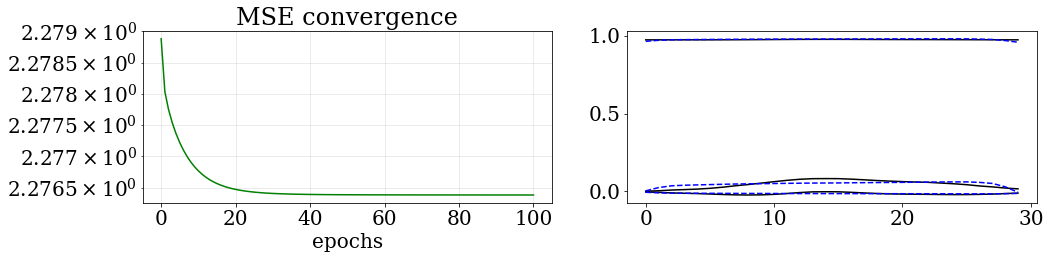

0.01376491644474729


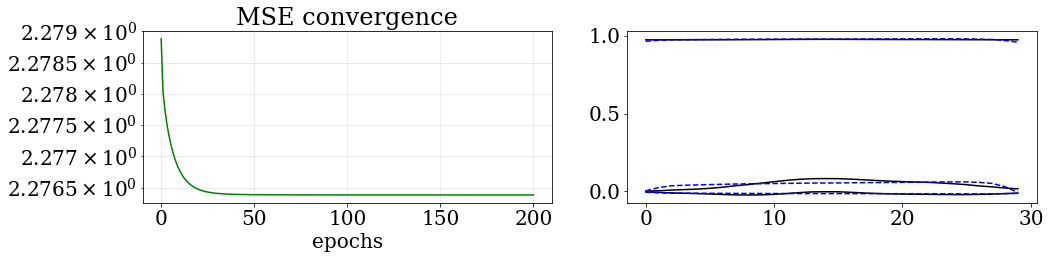

0.013764899322570434


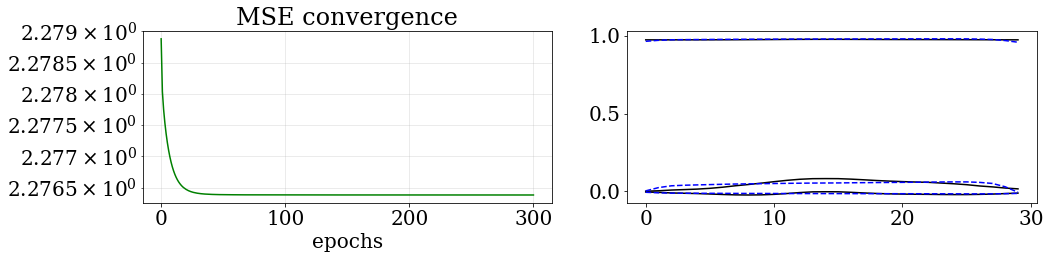

0.013764765146248959


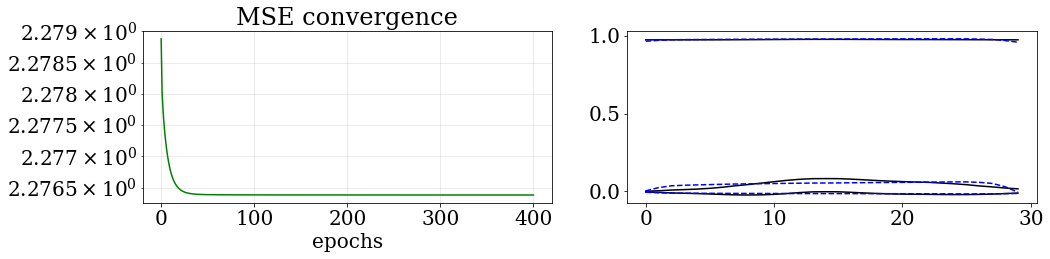

0.01376470679883826


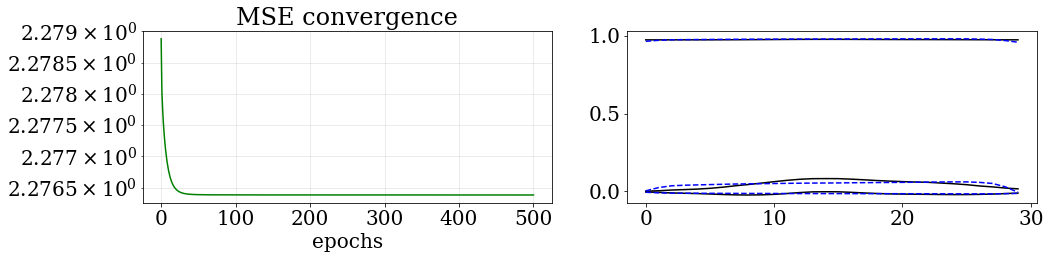

0.01376468828508207


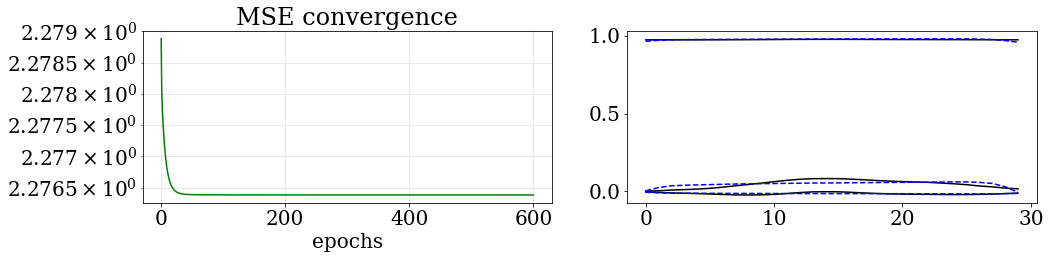

0.013764737740075668


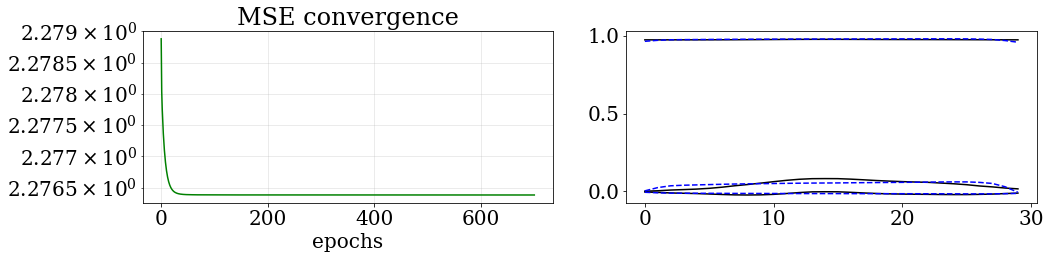

0.01376478874196476


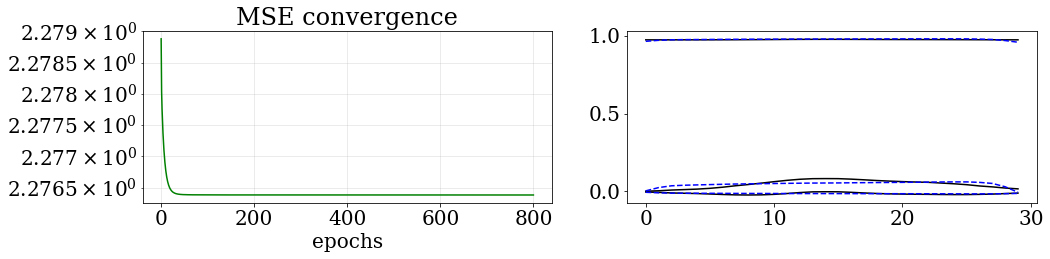

0.013764819059383504


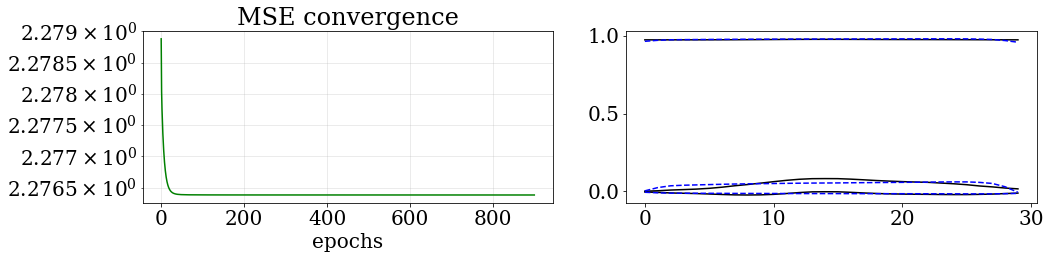

0.013764837219745607


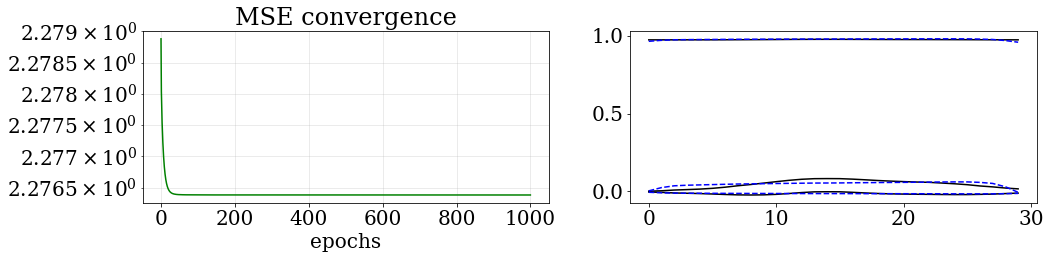

0.013764848152585833


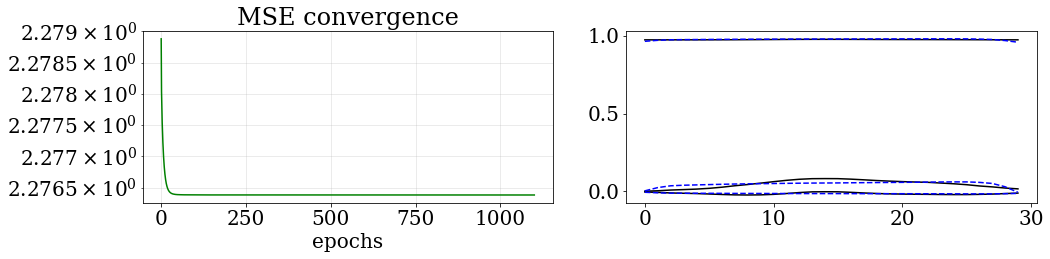

0.013764854754194356


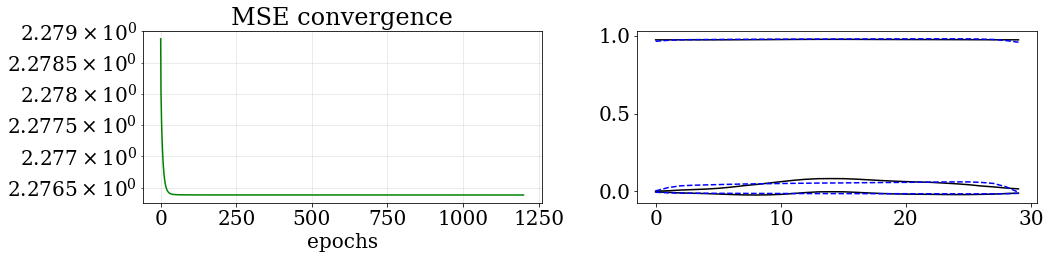

0.013764858747712105


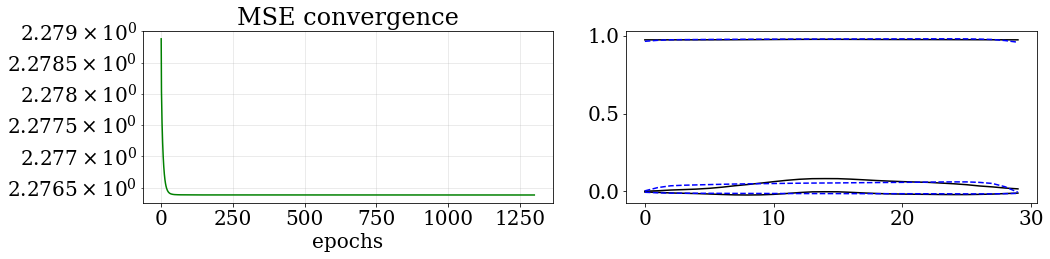

0.013764861166169255


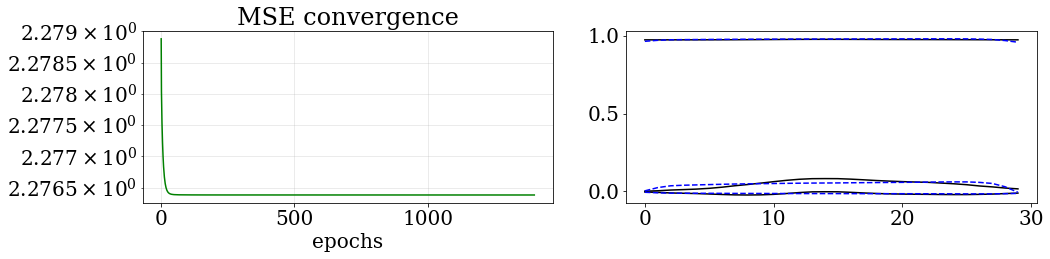

0.013764862631750025


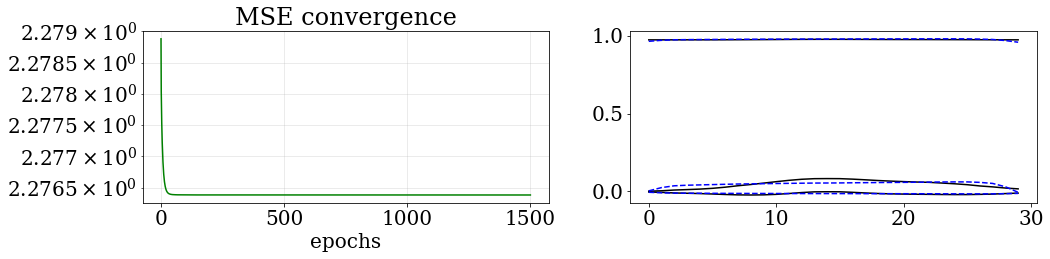

0.01376486352024685


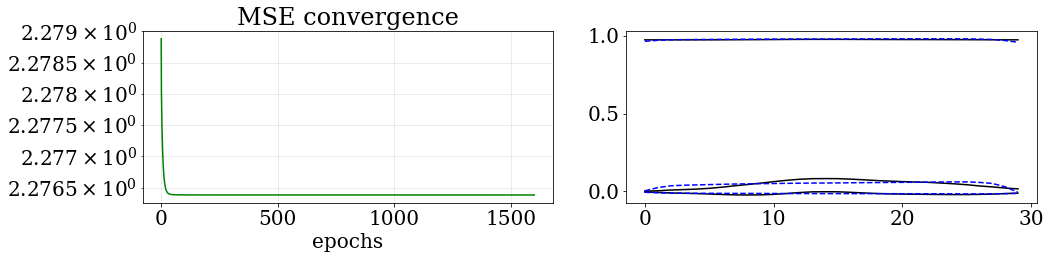

0.013764864059022353


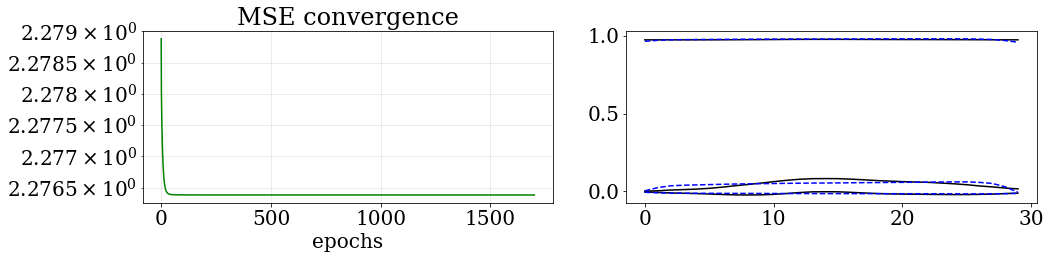

0.01376486438577861


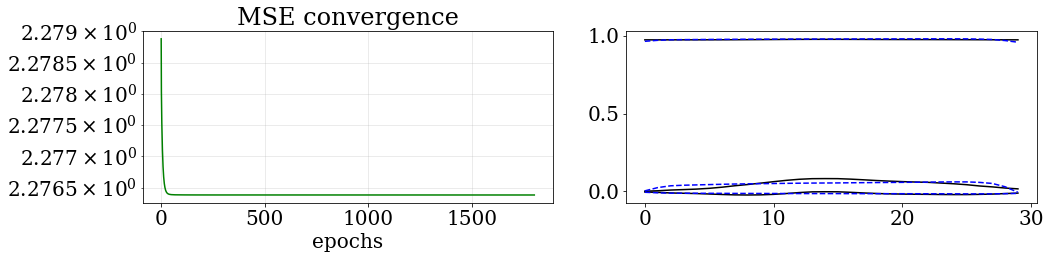

0.013764864583967263


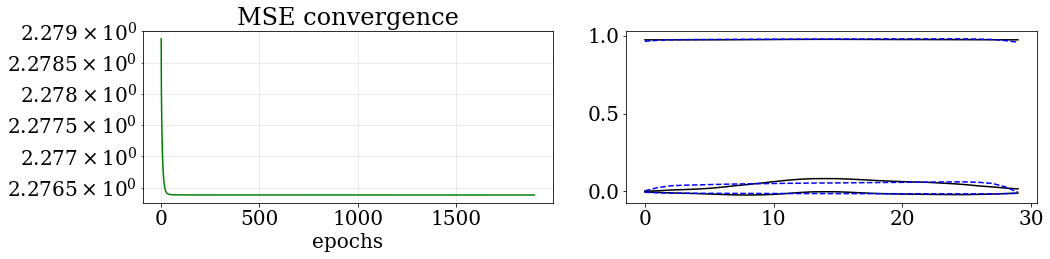

0.013764864704181864


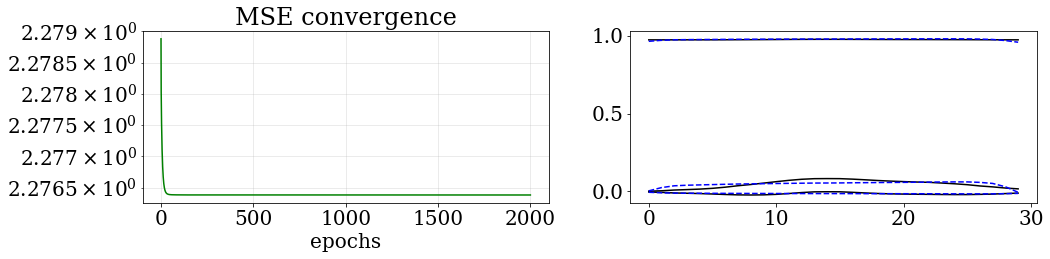

0.01376486477710237


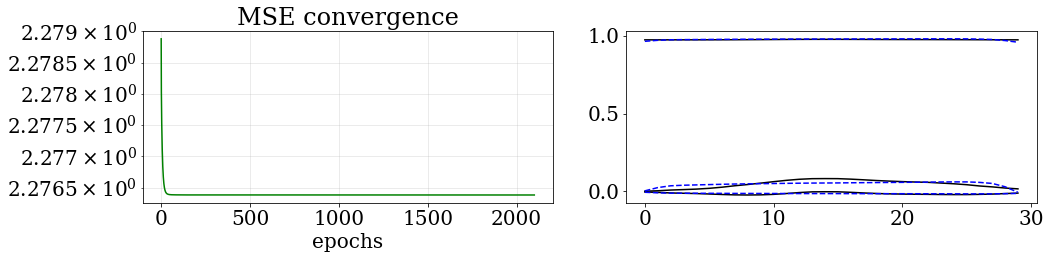

0.013764864821335834


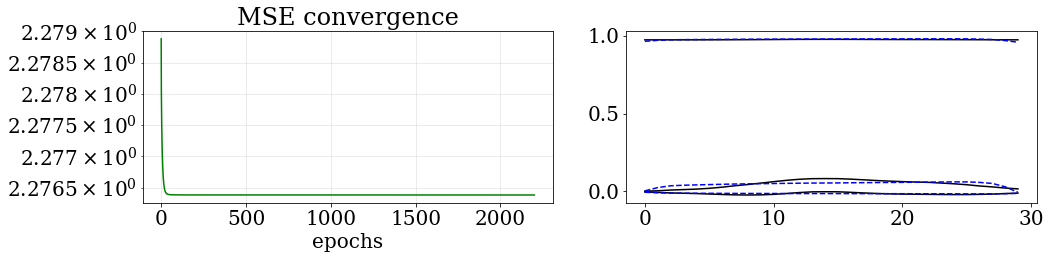

0.013764864848168091


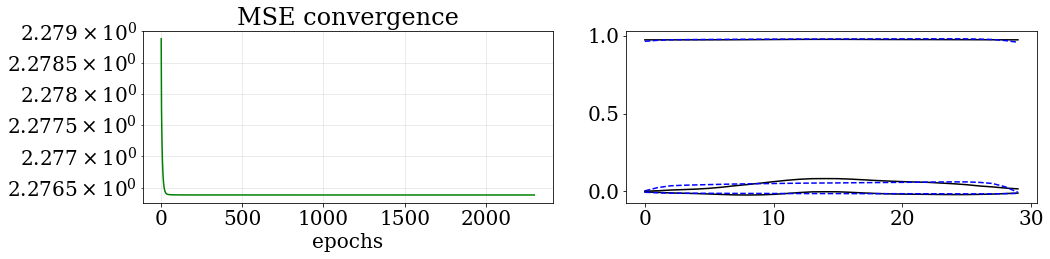

0.013764864864444809


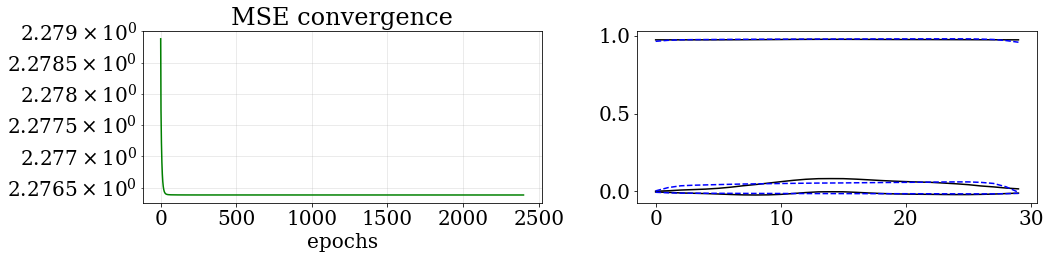

0.013764864874318454


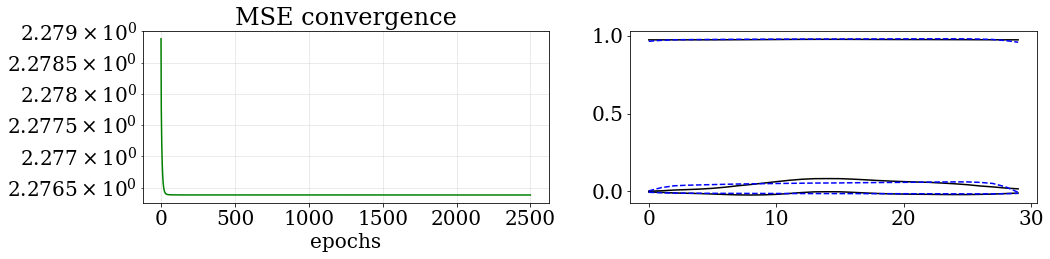

0.013764864880307951


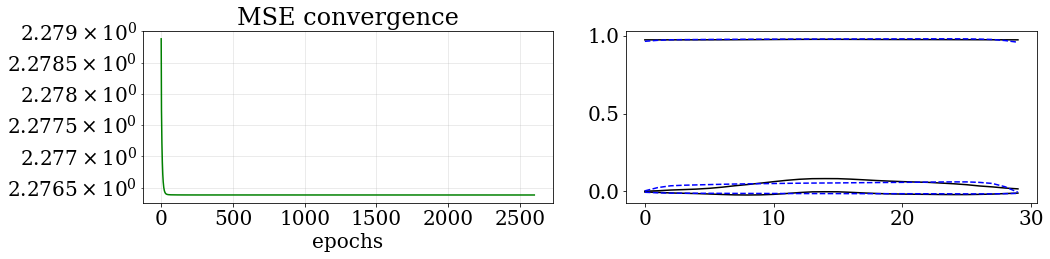

0.01376486488394126


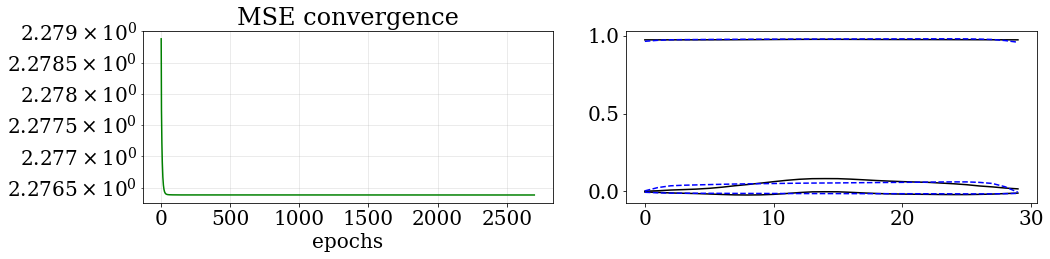

0.013764864886145284


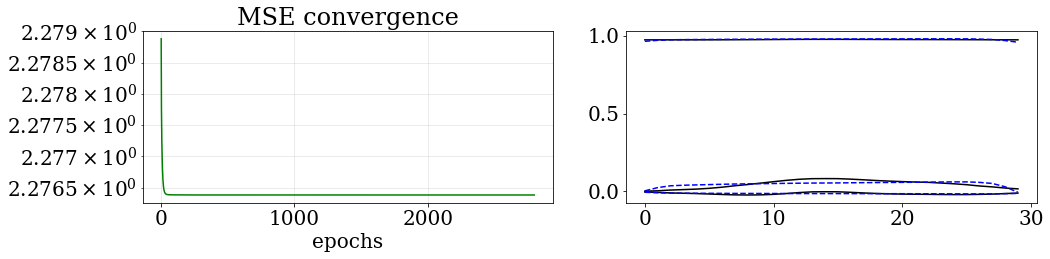

0.013764864887482279


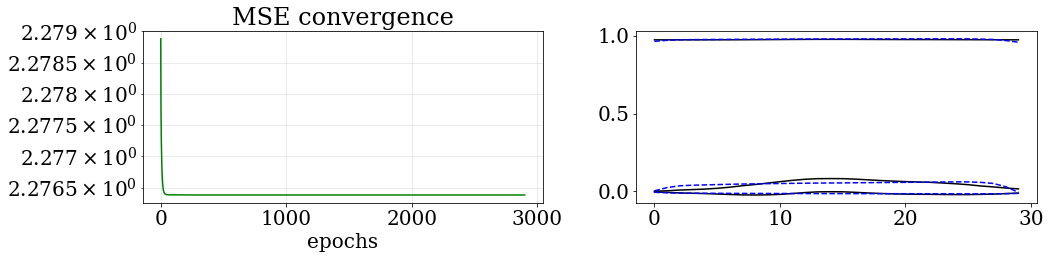

0.01376486488829332


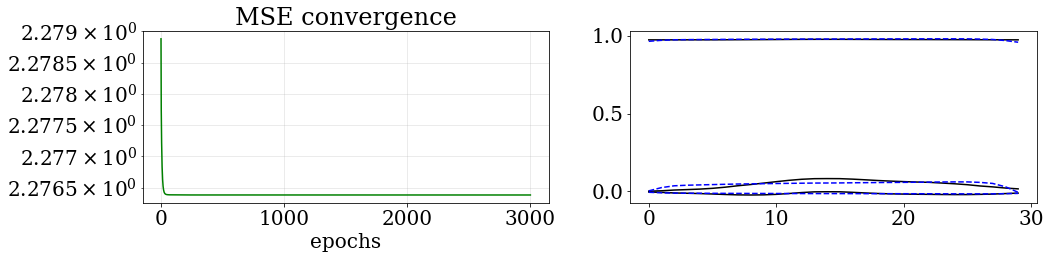

0.013764864888785306


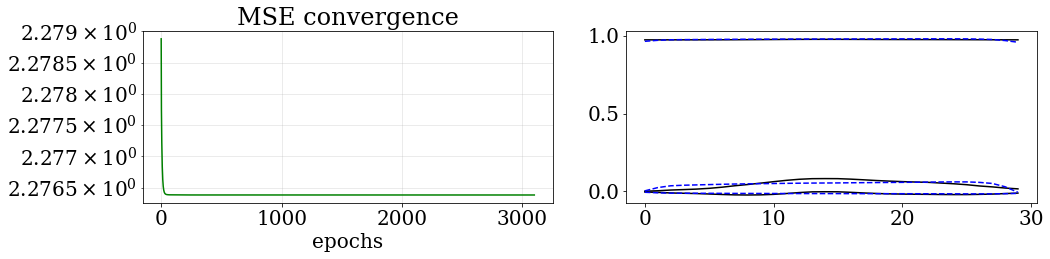

0.013764864889083765


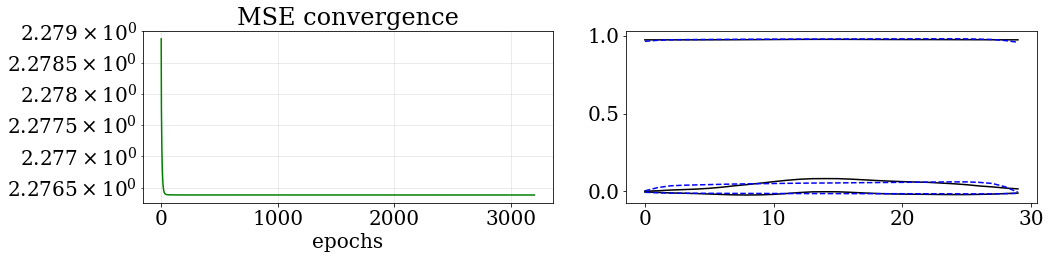

0.013764864889264797


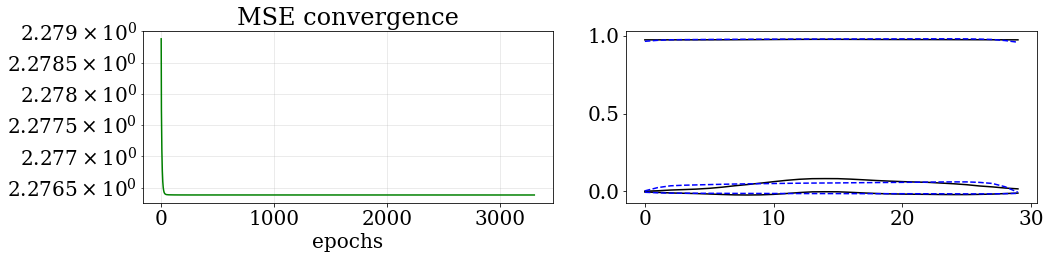

0.013764864889374631


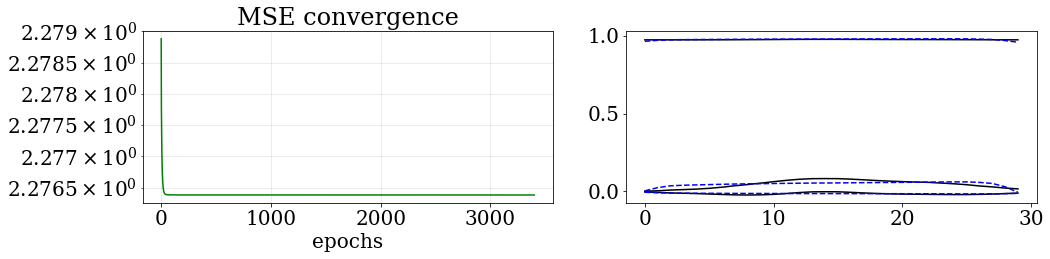

0.013764864889441245


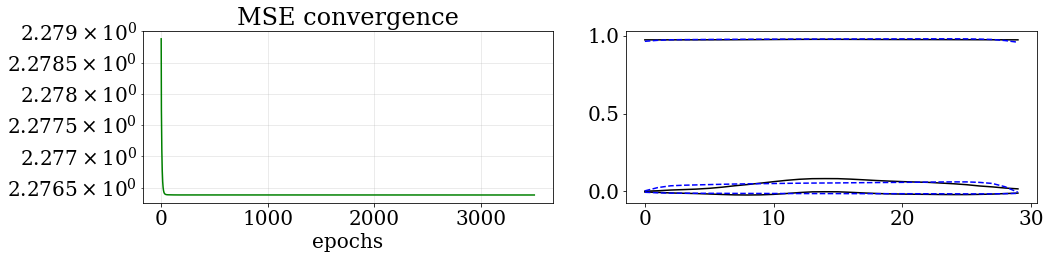

0.01376486488948165


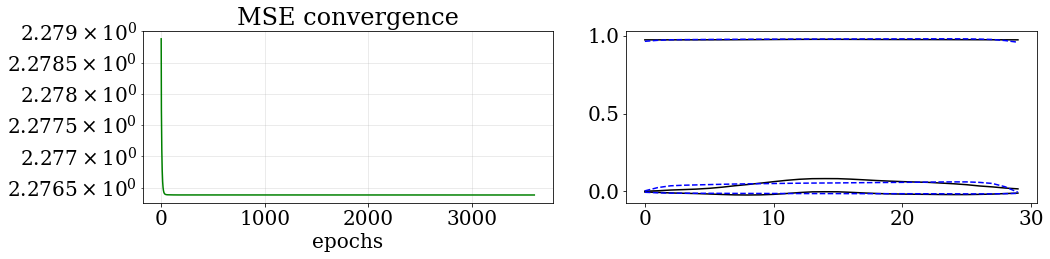

0.01376486488950617


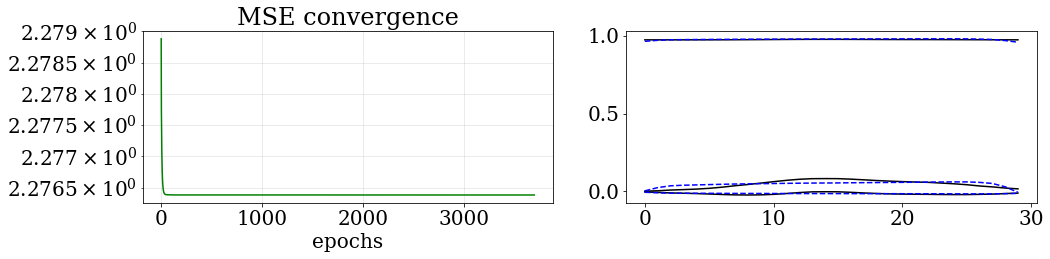

0.013764864889521037


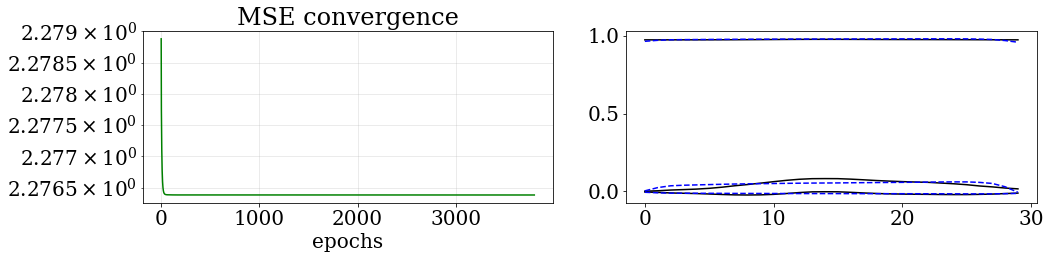

0.013764864889530048


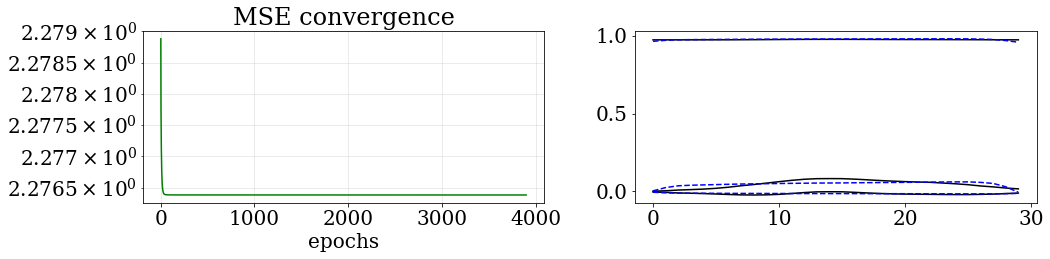

0.013764864889535525


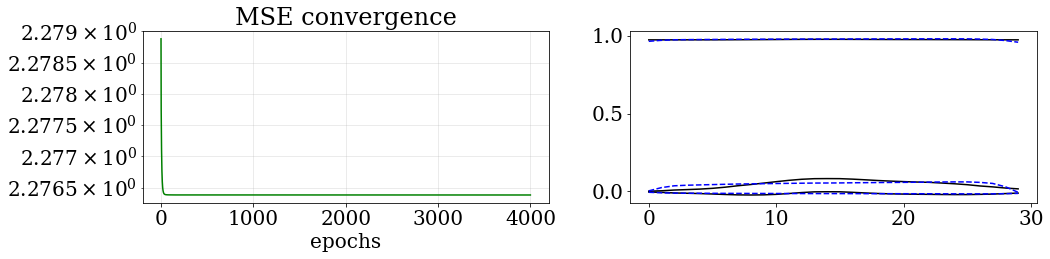

0.013764864889538854


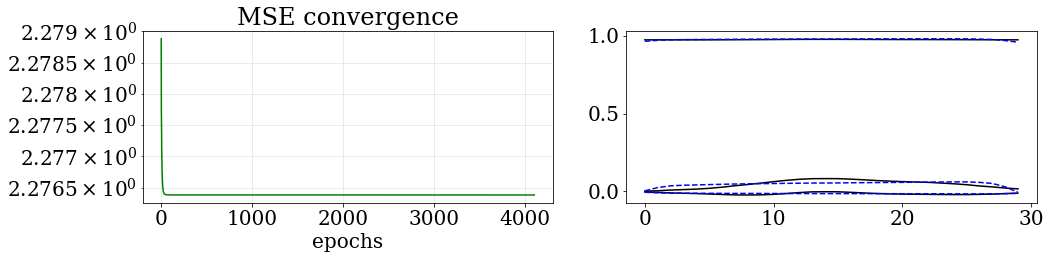

0.013764864889540863


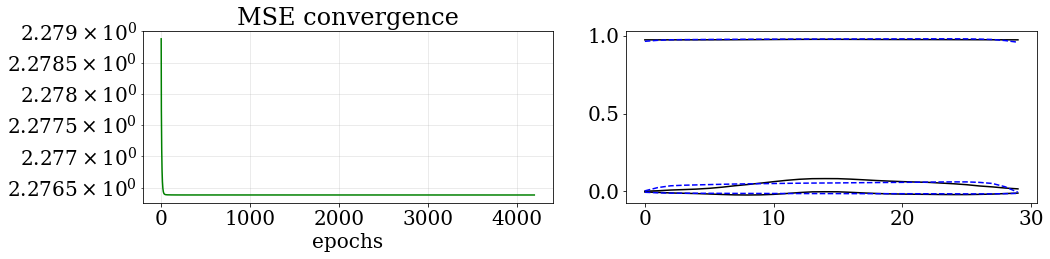

0.013764864889542075


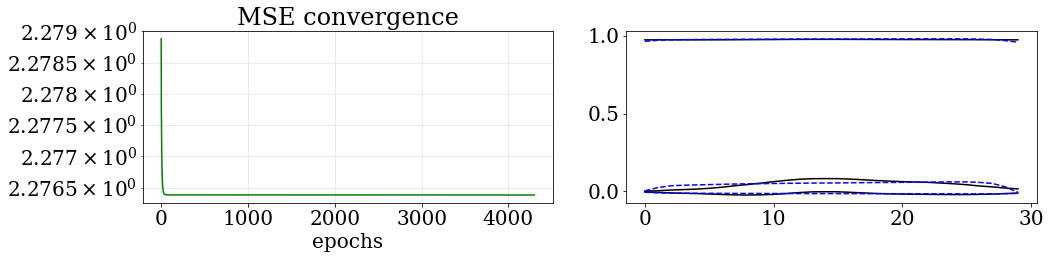

0.013764864889542821


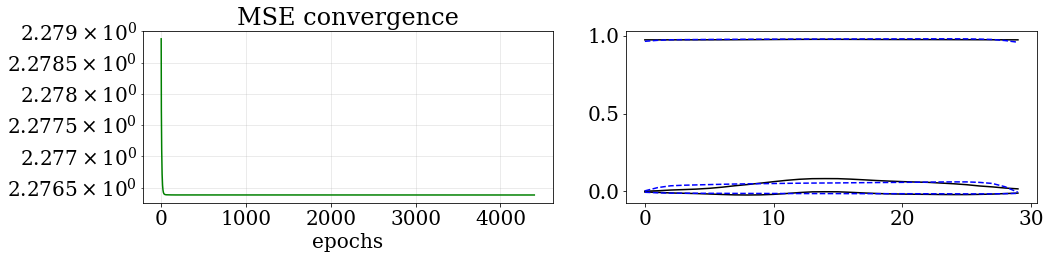

0.013764864889543264


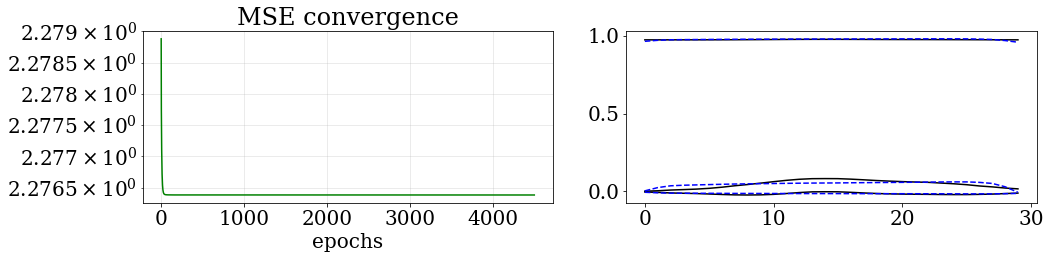

0.013764864889543515


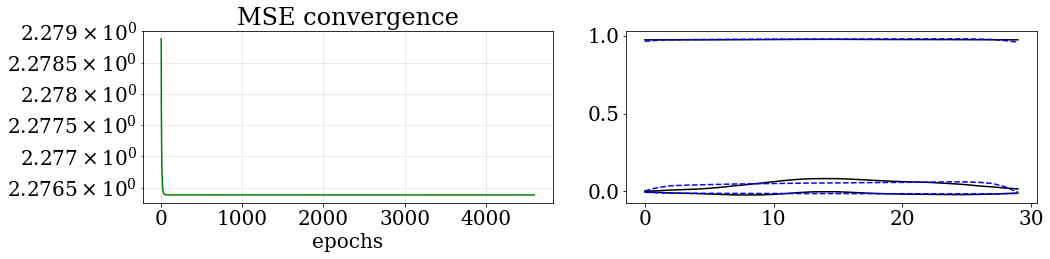

0.013764864889543722


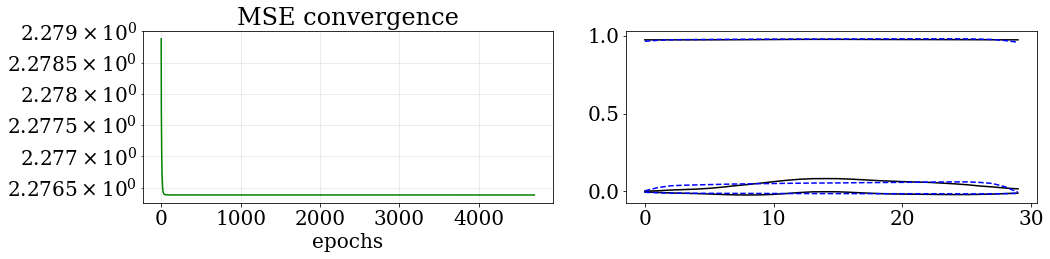

0.013764864889543803


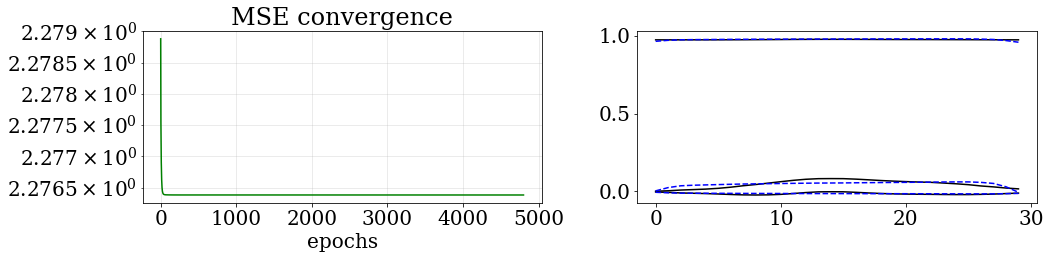

0.013764864889543895


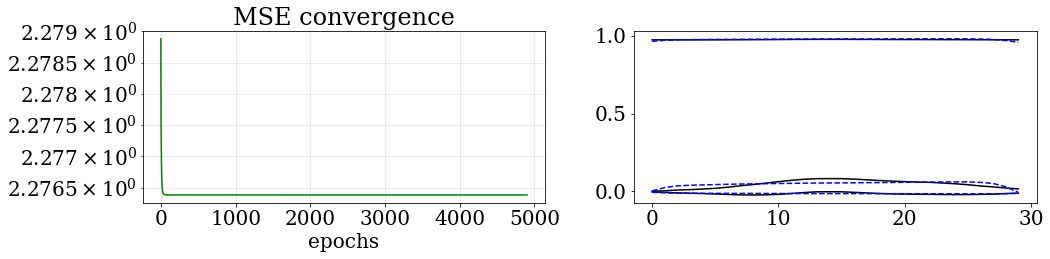

0.013764864889543926


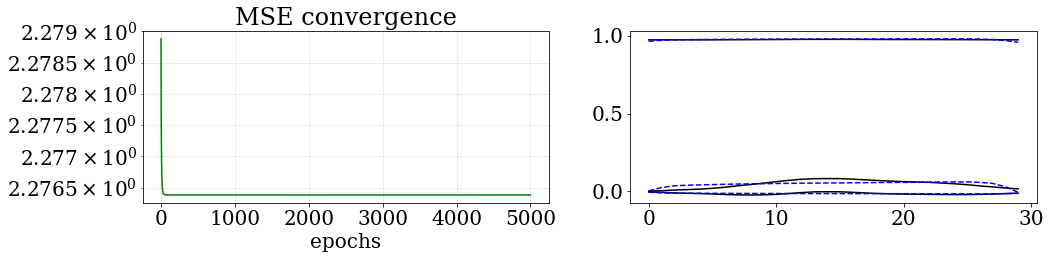

0.013764864889543952


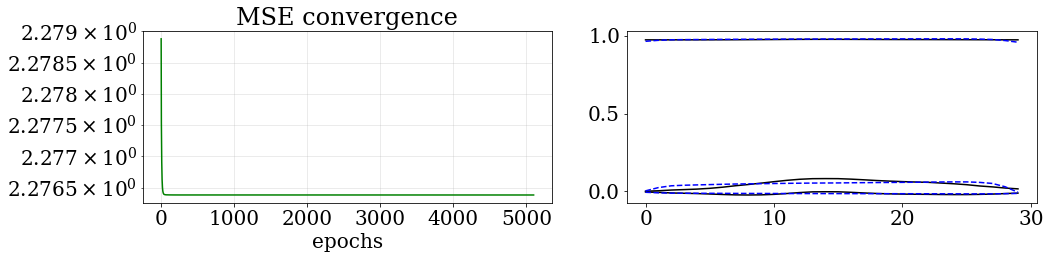

0.013764864889543949


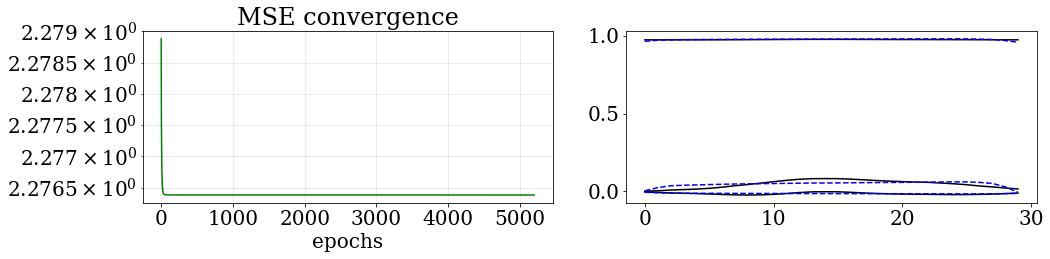

0.013764864889543973


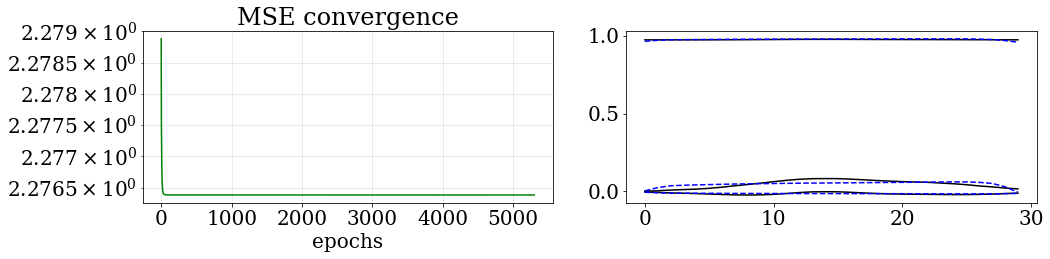

0.013764864889543975


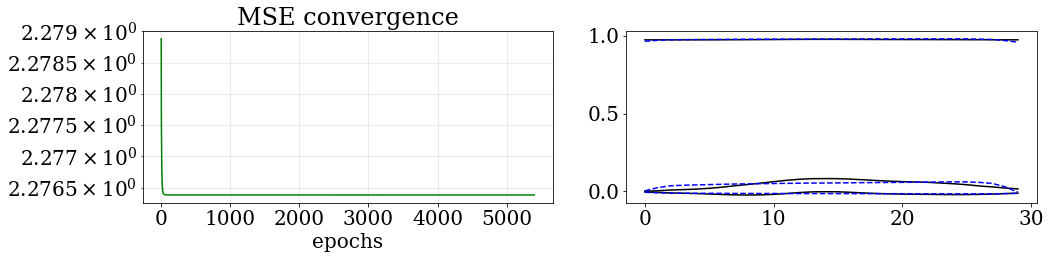

0.013764864889543992


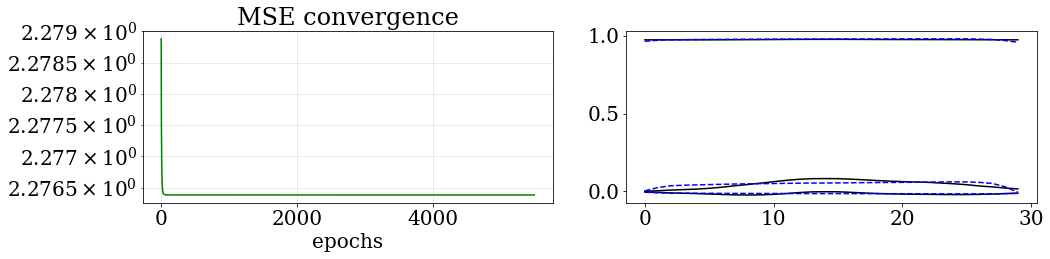

0.013764864889543992


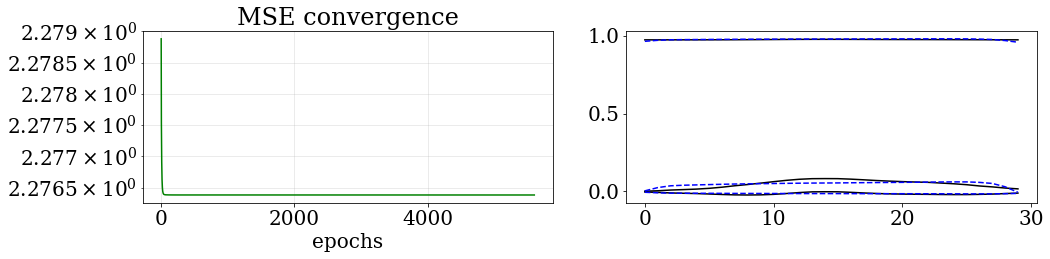

0.013764864889543992


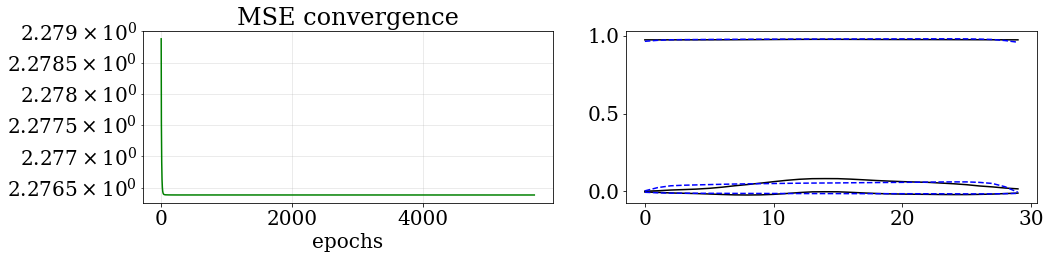

0.013764864889543994


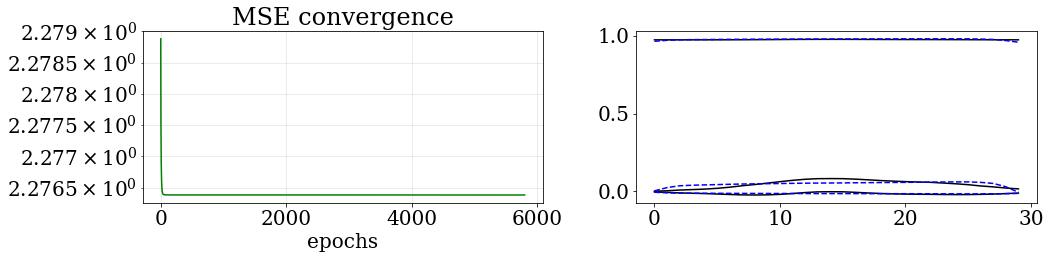

0.013764864889543994


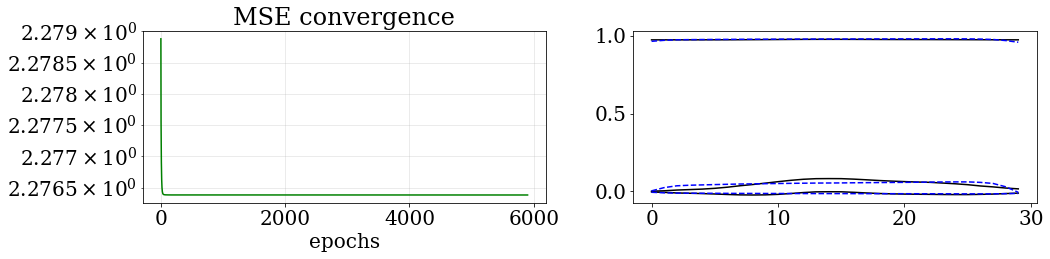

In [ ]:
plt.rcParams["figure.figsize"] = (15,4)
plt.rcParams["font.size"]  = 20

Loss_Mse    = tf.keras.losses.MeanSquaredError()

n_epochs    = 10001 #number of epochs

#define optimizer and initial learning rate   
optimizer   = tf.keras.optimizers.Adam(amsgrad=True) #amsgrad True for better convergence



l_rate                  = 0.001
optimizer.learning_rate = l_rate

lrate_update = True #flag for l_rate updating
lrate_mult   = 0.75
N_lr         = 100  #number of epochs before which the l_rate is not updated

# quantities to check and store the training and validation loss and the training goes on
old_loss      = np.zeros(n_epochs) #needed to evaluate training loss convergence
tloss_plot    = np.zeros(n_epochs) #training loss
vloss_plot    = np.zeros(n_epochs) #validation loss
tloss1_plot   = np.zeros(n_epochs) #training_der loss
vloss1_plot   = np.zeros(n_epochs) #validation_der loss
old_loss[0]  = 1e6 #initial value has to be high
N_check      = 5   #each N_check epochs we check convergence and validation loss
patience     = 200 #if the val_loss has not gone down in the last patience epochs, early stop
last_save    = patience

t            = 1 # initial (not important value) to monitor the time of the training

for epoch in range(n_epochs):
    
#     if epoch - last_save > patience: break #early stop
                
    #Perform gradient descent for all the batches every epoch
    loss_0 = 0
    loss_1 = 0
#     rng.shuffle(t_train, axis=0) #shuffle batches
    for j in range(n_batches):
#             print(j)
            loss, loss1, outs  = train_step1(x_train[j], Y_train[j], baseflow_train[j], model, f)
            loss_0 += loss
            loss_1 += loss1
            
#     ss
    
#     #save training loss each epoch
    loss_0             = loss_0.numpy()/n_batches/norm.numpy()
    loss_1             = loss_1.numpy()/n_batches/norm_der.numpy()
    tloss_plot[epoch]  = loss_0
    tloss1_plot[epoch] = loss_1
    

        
    if (epoch%100==0) and epoch != 0: 
        print(f.numpy())
        #plot convergence of training and validation loss
        plt.subplot(1,2,1)
        plt.title('MSE convergence')
        plt.yscale('log')
        plt.grid(True, axis="both", which='both', ls="-", alpha=0.3)
#         plt.plot(tloss_plot[np.nonzero(tloss_plot)], 'y', label='Train loss')
        plt.plot(tloss1_plot[np.nonzero(tloss_plot)], 'g', label='Train loss')


        plt.xlabel('epochs')
        plt.subplot(1,2,2)
        plt.plot(Y_train[-1], 'black')
        plt.plot(outs.numpy(), 'b--')

        
        plt.tight_layout()
        plt.show()
        
